Import required libraries

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(42)

defining some variables

In [2]:
sequence_length = 100
input_dim = 32
hidden_dim = 32
vocab_size = 1130

Input sequence

In [3]:
x = torch.randn(sequence_length, input_dim)

Defining LSTM parameters

In [4]:
# Forget gate
W_f = nn.Parameter(torch.randn(hidden_dim, input_dim + hidden_dim) * 0.1)
b_f = nn.Parameter(torch.zeros(hidden_dim))

# Input gate
W_i = nn.Parameter(torch.randn(hidden_dim, input_dim + hidden_dim) * 0.1)
b_i = nn.Parameter(torch.zeros(hidden_dim))

# Candidate cell state
W_c = nn.Parameter(torch.randn(hidden_dim, input_dim + hidden_dim) * 0.1)
b_c = nn.Parameter(torch.zeros(hidden_dim))

# Output gate
W_o = nn.Parameter(torch.randn(hidden_dim, input_dim + hidden_dim) * 0.1)
b_o = nn.Parameter(torch.zeros(hidden_dim))


Defining output layer

In [5]:
W_out = nn.Parameter(
    torch.randn(vocab_size, hidden_dim) * 0.1
)

b_out = nn.Parameter(
    torch.zeros(vocab_size)
)


Defining initial states

In [6]:
h = torch.zeros(hidden_dim)
c = torch.zeros(hidden_dim)

hidden_states = []
cell_states = []

Running LSTM at one time step

In [7]:
for t in range(sequence_length):

    x_t = x[t]

    # --------------------------------------------------------
    # Combine current input and previous hidden state
    # --------------------------------------------------------

    combined = torch.cat([x_t, h])


    # --------------------------------------------------------
    # FORGET GATE
    # --------------------------------------------------------

    f_t = torch.sigmoid(W_f @ combined + b_f)


    # --------------------------------------------------------
    # INPUT GATE
    # --------------------------------------------------------

    i_t = torch.sigmoid(W_i @ combined + b_i)


    # --------------------------------------------------------
    # CANDIDATE MEMORY
    # --------------------------------------------------------

    c_candidate = torch.tanh(
        W_c @ combined + b_c
    )


    # --------------------------------------------------------
    # UPDATE CELL STATE
    # --------------------------------------------------------

    c = f_t * c + i_t * c_candidate


    # --------------------------------------------------------
    # OUTPUT GATE
    # --------------------------------------------------------

    o_t = torch.sigmoid(
        W_o @ combined + b_o
    )


    # --------------------------------------------------------
    # UPDATE HIDDEN STATE
    # --------------------------------------------------------

    h = o_t * torch.tanh(c)


    # Keep gradients for analysis
    h.retain_grad()
    c.retain_grad()

    hidden_states.append(h)
    cell_states.append(c)

Making prediction on the final state

In [8]:
final_hidden = hidden_states[-1]

logits = W_out @ final_hidden + b_out

target = torch.randint(0, vocab_size, (1,))

Evaluating loss

In [9]:
loss = F.cross_entropy(
    logits.unsqueeze(0),
    target
)

print("Loss:", loss.item())


Loss: 6.938504219055176


Computing Backprop

In [10]:
loss.backward()

Collect gradient magnitudes to observe the performance in comparison to RNN problems

In [11]:
hidden_gradient_norms = []
cell_gradient_norms = []

for t in range(sequence_length):

    h_grad = hidden_states[t].grad.norm().item()
    c_grad = cell_states[t].grad.norm().item()

    hidden_gradient_norms.append(h_grad)
    cell_gradient_norms.append(c_grad)

Print some gradient values

In [12]:
print("\nGradient magnitudes:\n")

for t in [0, 1, 2, 9, 19, 49, 79, 89, 98, 99]:

    print(
        f"Time step {t + 1:3d} | "
        f"h gradient = {hidden_gradient_norms[t]:.10e} | "
        f"c gradient = {cell_gradient_norms[t]:.10e}"
    )



Gradient magnitudes:

Time step   1 | h gradient = 1.2262109447e-21 | c gradient = 3.0757382257e-21
Time step   2 | h gradient = 2.3094028461e-21 | c gradient = 4.6369733734e-21
Time step   3 | h gradient = 3.2116908928e-21 | c gradient = 6.8100931648e-21
Time step  10 | h gradient = 1.0296973032e-19 | c gradient = 2.1804907462e-19
Time step  20 | h gradient = 1.4538483433e-17 | c gradient = 2.9091118272e-17
Time step  50 | h gradient = 8.0913886702e-12 | c gradient = 1.9094201914e-11
Time step  80 | h gradient = 8.3582999650e-06 | c gradient = 1.5598905520e-05
Time step  90 | h gradient = 5.7106866734e-04 | c gradient = 1.2158119353e-03
Time step  99 | h gradient = 7.5969867408e-02 | c gradient = 1.3848401606e-01
Time step 100 | h gradient = 5.9389221668e-01 | c gradient = 2.6596301794e-01


Visualize Gradient values

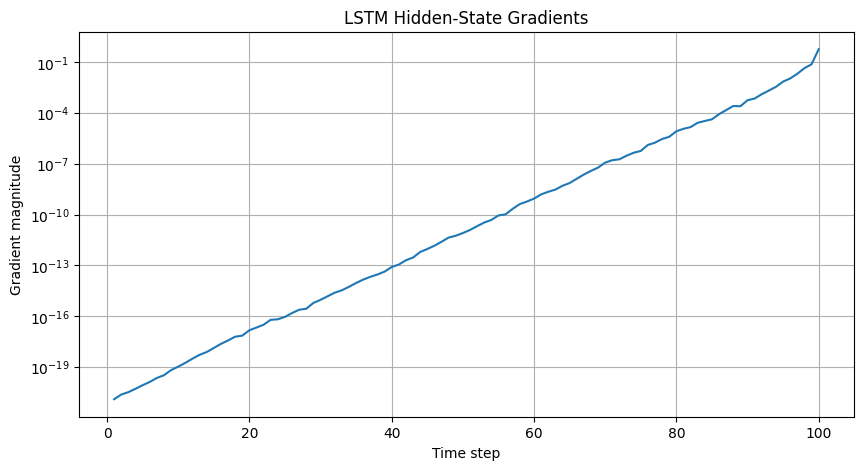

In [13]:

plt.figure(figsize=(10, 5))

plt.plot(
    range(1, sequence_length + 1),
    hidden_gradient_norms
)

plt.xlabel("Time step")
plt.ylabel("Gradient magnitude")
plt.title("LSTM Hidden-State Gradients")

plt.yscale("log")
plt.grid()

plt.show()

Visualizing cell-state gradient

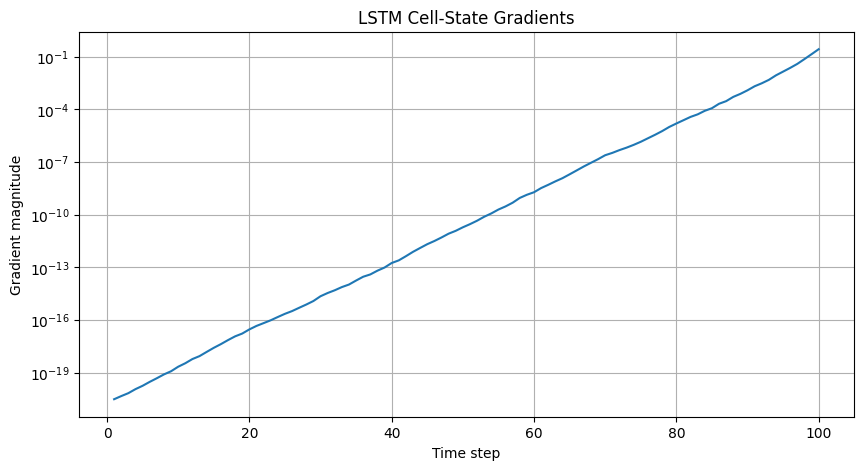

In [14]:
plt.figure(figsize=(10, 5))

plt.plot(
    range(1, sequence_length + 1),
    cell_gradient_norms
)

plt.xlabel("Time step")
plt.ylabel("Gradient magnitude")
plt.title("LSTM Cell-State Gradients")

plt.yscale("log")
plt.grid()

plt.show()